In [ ]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime

csv_path = "../data/raw/wildfire/AK_fire_location_points_NAD83.csv"
try:
    df = pd.read_csv(csv_path, usecols=['FIRESEASON','DISCOVERYDATETIME','ESTIMATEDTOTALACRES','SPECIFICCAUSE','LATITUDE','LONGITUDE'], engine='c')
except Exception as e:
    print('Warning: primary CSV read failed — retrying with python engine (skipping bad lines). Error:', e)
    df = pd.read_csv(csv_path, usecols=['FIRESEASON','DISCOVERYDATETIME','ESTIMATEDTOTALACRES','SPECIFICCAUSE','LATITUDE','LONGITUDE'], engine='python', on_bad_lines='skip')

df = df[pd.to_numeric(df['FIRESEASON'], errors='coerce').notna()]
df['year'] = df['FIRESEASON'].astype(int)

output_dir = "../outputs/figures/wildfire_graphs/"
os.makedirs(output_dir, exist_ok=True)

In [ ]:
fires_per_year = df.groupby('year').size()

plt.figure(figsize=(15,7))
fires_per_year.plot(kind='bar', color='orange')
plt.xlabel("Year", fontsize=14)
plt.ylabel("Number of Fires", fontsize=14)
plt.title("Number of Wildfires per Year", fontsize=16)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "fires_per_year.png"))
plt.show()

In [ ]:
df['DISCOVERYDATETIME'] = pd.to_datetime(df['DISCOVERYDATETIME'], errors='coerce')
df['month'] = df['DISCOVERYDATETIME'].dt.month

fires_per_month = df.groupby('month').size()

plt.figure(figsize=(10,5))
fires_per_month.plot(kind='bar', color='green')
plt.xlabel("Month", fontsize=14)
plt.ylabel("Number of Fires", fontsize=14)
plt.title("Wildfires per Month", fontsize=16)
plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "fires_per_month.png"))
plt.show()

In [ ]:
df['SPECIFICCAUSE'] = df['SPECIFICCAUSE'].str.title()
df['SPECIFICCAUSE'].fillna('Unknown', inplace=True)

fires_by_cause = df['SPECIFICCAUSE'].value_counts().head(10)

plt.figure(figsize=(10,6))
fires_by_cause.plot(kind='barh', color='skyblue')
plt.xlabel("Number of Fires", fontsize=14)
plt.ylabel("Cause", fontsize=14)
plt.title("Top 10 Causes of Wildfires", fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "top_fire_causes.png"))
plt.show()

In [ ]:
burned_acres = df.groupby('year')['ESTIMATEDTOTALACRES'].sum()

plt.figure(figsize=(15,7))
burned_acres.plot(kind='line', marker='o', color='red')
plt.xlabel("Year", fontsize=14)
plt.ylabel("Total Burned Acres", fontsize=14)
plt.title("Total Burned Acres per Year", fontsize=16)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "burned_acres_per_year.png"))
plt.show()

In [ ]:
wf_path = Path('..') / 'data' / 'raw' / 'wildfire' / 'AK_fire_location_points_NAD83.csv'
output_dir = Path('..') / 'outputs' / 'figures' / 'wildfire_graphs'
output_dir.mkdir(parents=True, exist_ok=True)

df_wf = pd.read_csv(wf_path, dtype=str)
df_wf.columns = [c.strip() for c in df_wf.columns]

for col in ['ACTUALTOTALACRES', 'ESTIMATEDTOTALACRES', 'DISCOVERYSIZE', 'IASIZE']:
    if col in df_wf.columns:
        df_wf[col] = pd.to_numeric(df_wf[col], errors='coerce')

if 'DISCOVERYDATETIME' in df_wf.columns:
    df_wf['DISCOVERYDATETIME'] = pd.to_datetime(df_wf['DISCOVERYDATETIME'], errors='coerce')
    current_year = datetime.now().year
    if df_wf['DISCOVERYDATETIME'].dt.year.max() > current_year:
        def _fix_dt(dt):
            if pd.isna(dt):
                return dt
            y = dt.year
            if y > current_year:
                y2 = y - 100
                if 1900 <= y2 <= current_year:
                    try:
                        return dt.replace(year=y2)
                    except Exception:
                        return dt
            return dt
        df_wf['DISCOVERYDATETIME'] = df_wf['DISCOVERYDATETIME'].apply(_fix_dt)

if 'DISCOVERYDATETIME' in df_wf.columns and df_wf['DISCOVERYDATETIME'].notna().any():
    df_wf['year'] = df_wf['DISCOVERYDATETIME'].dt.year
elif 'FIRESEASON' in df_wf.columns:
    df_wf['year'] = pd.to_numeric(df_wf['FIRESEASON'], errors='coerce')
else:
    df_wf['year'] = np.nan

if 'FIRESEASON' in df_wf.columns:
    fs_numeric = pd.to_numeric(df_wf['FIRESEASON'], errors='coerce')
    future_mask = df_wf['year'] > current_year
    if future_mask.any():
        use_fs = (~fs_numeric.isna()) & (fs_numeric <= current_year) & (fs_numeric >= 1900)
        replace_mask = future_mask & use_fs
        if replace_mask.any():
            df_wf.loc[replace_mask, 'year'] = fs_numeric[replace_mask]

df_wf['burned_acres'] = df_wf.get('ACTUALTOTALACRES').fillna(df_wf.get('ESTIMATEDTOTALACRES')).fillna(df_wf.get('DISCOVERYSIZE'))
df_wf['GENERALCAUSE'] = df_wf.get('GENERALCAUSE', pd.Series(index=df_wf.index)).fillna('Undetermined')


if 'year' in df_wf.columns:
    acres_by_year = df_wf.groupby('year')['burned_acres'].sum().sort_index()
    acres_by_year = acres_by_year[~acres_by_year.index.isna()]
    valid_idx = (acres_by_year.index.astype(float) >= 1900) & (acres_by_year.index.astype(float) <= current_year)
    acres_by_year = acres_by_year[valid_idx]
    plt.figure(figsize=(10,5))
    plt.plot(acres_by_year.index.astype(int), acres_by_year.values, marker='o')
    plt.title('Total Burned Acres per Year')
    plt.xlabel('Year')
    plt.ylabel('Total burned acres')
    plt.grid(True)
    plt.xticks(acres_by_year.index.astype(int), rotation=45)
    plt.tight_layout()
    plt.savefig(output_dir / 'burned_acres_per_year.png', dpi=150)
    plt.show()
else:
    print('No year information available to plot burned acres per year.')


/var/folders/my/bhr938sj53g4x64y8t7ljrd80000gn/T/ipykernel_27816/3331888118.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_spec.values, y=top_spec.index, palette='rocket')


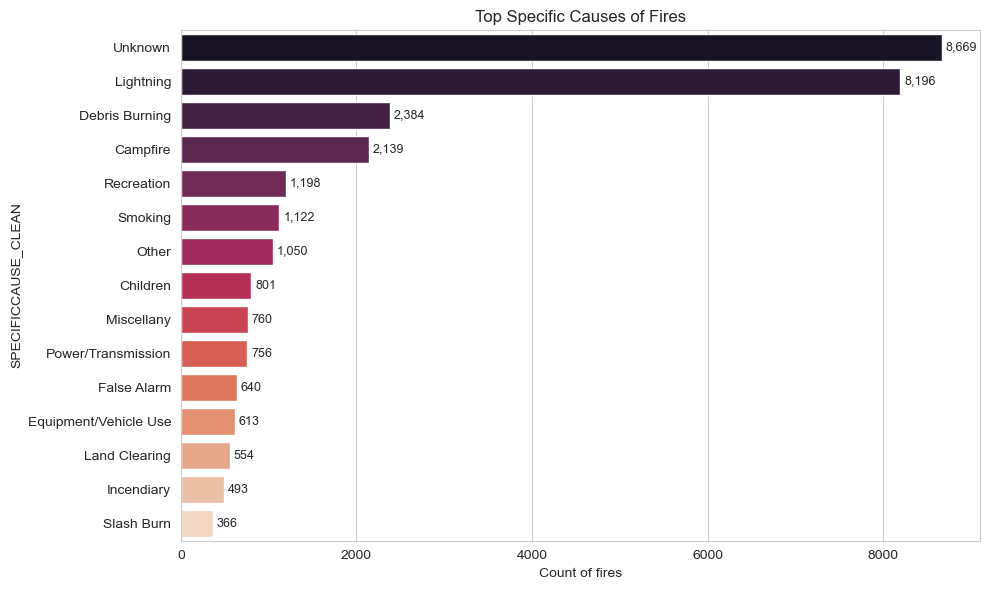

Saved cleaned SPECIFICCAUSE counts to: ../outputs/figures/wildfire_graphs/specificcause_counts_cleaned.csv

Top specific causes (cleaned counts):


SPECIFICCAUSE_CLEAN
Unknown                  8669
Lightning                8196
Debris Burning           2384
Campfire                 2139
Recreation               1198
Smoking                  1122
Other                    1050
Children                  801
Miscellany                760
Power/Transmission        756
False Alarm               640
Equipment/Vehicle Use     613
Land Clearing             554
Incendiary                493
Slash Burn                366
Name: count, dtype: int64

In [35]:
if 'df_wf' in globals():
    if 'SPECIFICCAUSE' in df_wf.columns:
       #replace common columns 
        def canonicalize_specific(s):
            if pd.isna(s):
                return 'Unknown'
            s0 = str(s).strip()
            if not s0:
                return 'Unknown'
            s1 = s0.lower()
            if 'lightn' in s1: 
                return 'Lightning'
            if 'debris' in s1 or 'bng' in s1 or 'brn' in s1:
                return 'Debris Burning'
            if 'camp' in s1:
                return 'Campfire'
            if 'false' in s1:
                return 'False Alarm'
            if 'child' in s1:
                return 'Children'
            if 'smok' in s1:
                return 'Smoking'
            if 'recreat' in s1 or 'recreation' in s1:
                return 'Recreation'
            if 'equipment' in s1 or 'vehicle' in s1 or 'ohv' in s1:
                return 'Equipment/Vehicle Use'
            if 'rail' in s1:
                return 'Railroad'
            if 'power' in s1 or 'electrical' in s1:
                return 'Power/Transmission'
            if 'unknown' in s1 or 'undetermined' in s1:
                return 'Unknown'
            return s0.title()

        df_wf['SPECIFICCAUSE_CLEAN'] = df_wf['SPECIFICCAUSE'].apply(canonicalize_specific)
        spec_clean_counts = df_wf['SPECIFICCAUSE_CLEAN'].value_counts()
        top_n = 15
        top_spec = spec_clean_counts.head(top_n)

        plt.figure(figsize=(10,6))
        ax = sns.barplot(x=top_spec.values, y=top_spec.index, palette='rocket')
        plt.title('Top Specific Causes of Fires')
        plt.xlabel('Count of fires')

        x_offset = top_spec.values.max() * 0.005 if top_spec.values.size else 0.0
        for p, val in zip(ax.patches, top_spec.values):
            ax.annotate(f"{int(val):,}", (p.get_width() + x_offset, p.get_y() + p.get_height()/2), va='center', ha='left', fontsize=9)

        plt.tight_layout()
        plt.savefig(output_dir / f'top_specific_causes_bar.png', dpi=150)
        plt.show()

        cleaned_out = output_dir / 'specificcause_counts_cleaned.csv'
        spec_clean_counts.to_csv(cleaned_out, header=['count'])
        print(f"Saved cleaned SPECIFICCAUSE counts to: {cleaned_out}")

        print('\nTop specific causes (cleaned counts):')
        display(top_spec)
    else:
        print('SPECIFICCAUSE column not found in dataframe')
else:
    print('df_wf not loaded — run the data load cell first')
